## 2D model identified + analyses

\begin{align}
\dot{x}_0 &= -0.516 
+ 0.298\,x_0
+ 1.849\,x_1
+ 0.407\,x_0^2
+ 1.675\,x_0 x_1
+ 1.284\,x_1^2
- 0.127\,x_0^3
- 0.390\,x_0^2 x_1
- 0.422\,x_0 x_1^2
- 0.141\,x_1^3
\\
\dot{x}_1 &= -0.673
- 0.163\,x_0
+ 0.839\,x_1
+ 0.508\,x_0^2
+ 1.663\,x_0 x_1
+ 1.230\,x_1^2
- 0.137\,x_0^3
- 0.409\,x_0^2 x_1
- 0.423\,x_0 x_1^2
- 0.144\,x_1^3
\end{align}\\


In [1]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# import scienceplots
# plt.style.use(['science', 'ieee'])
# plt.rc('font', size=14)

In [2]:
def f(t, x, u=0.0):
    x0, x1 = x

    uu = u(t, x) if callable(u) else float(u)
    
    dx0 = ((-0.516) + 0.298*x0 + 1.849*x1 + 0.407*x0**2 + 1.675*x0*x1 + 1.284*x1**2 - 0.127*x0**3 - 0.390*x0**2*x1 - 0.422*x0*x1**2 - 0.141*x1**3)
    dx1 = ((-0.673) - 0.163*x0 + 0.839*x1 + 0.508*x0**2 + 1.663*x0*x1 + 1.230*x1**2 - 0.137*x0**3 - 0.409*x0**2*x1 - 0.423*x0*x1**2 - 0.144*x1**3)

    dx0 = dx0 + uu

    return np.array([dx0, dx1], dtype=float)

In [3]:
def simulate_rk4(x0, t0=0.0, tf=20.0, dt=0.01, u=0.0):

    n = int(np.floor((tf - t0) / dt)) + 1
    t = t0 + dt*np.arange(n, dtype=float)
    X = np.empty((2, n), dtype=float)
    X[:, 0] = np.array(x0, dtype=float)

    for k in range(n - 1):
        tk = t[k]
        xk = X[:, k]

        k1 = f(tk, xk, u=u)
        k2 = f(tk + 0.5*dt, xk + 0.5*dt*k1, u=u)
        k3 = f(tk + 0.5*dt, xk + 0.5*dt*k2, u=u)
        k4 = f(tk + dt,     xk + dt*k3,     u=u)

        X[:, k+1] = xk + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

        if not np.isfinite(X[:, k+1]).all():
            X = X[:, :k+2]
            t = t[:k+2]
            break

    return t, X

Basic simulation

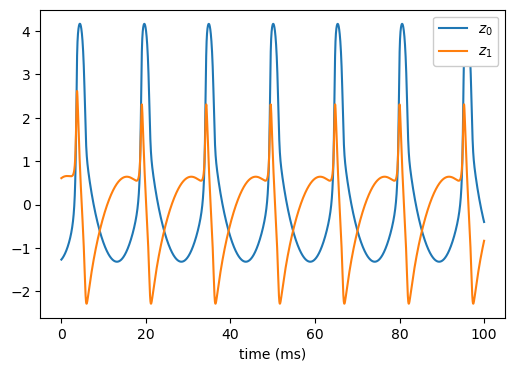

In [4]:
t, X = simulate_rk4(x0=[-1.26607113,  0.60911538], tf=100.0, dt=0.01)

plt.figure(figsize=(6,4))
plt.plot(t, X[0], label='$z_0$')
plt.plot(t, X[1], label='$z_1$')
plt.xlabel("time (ms)")
plt.legend(loc='upper right', frameon=True, framealpha=1.0)
plt.show()

Equilibrium points and local stability (Jacobian)

In [ ]:
def jacobian(x):
    x0, x1 = x

    # ddx0/dx0
    a11 = (0.298 + 2*0.407*x0 + 1.675*x1 - 3*0.127*x0**2 - 2*0.390*x0*x1 - 0.422*x1**2)
    # ddx0/dx1
    a12 = (1.849 + 1.675*x0 + 2*1.284*x1 - 0.390*x0**2 - 2*0.422*x0*x1 - 3*0.141*x1**2)
    
    # ddx1/dx0
    a21 = (-0.163 + 2*0.508*x0 + 1.663*x1 - 3*0.137*x0**2 - 2*0.409*x0*x1 - 0.423*x1**2)
    # ddx1/dx1
    a22 = (0.839 + 1.663*x0 + 2*1.230*x1 - 0.409*x0**2 - 2*0.423*x0*x1 - 3*0.144*x1**2)

    return np.array([[a11, a12], [a21, a22]], dtype=float)

# Newton
def newton_equilibrium(x_init, max_iter=30, tol=1e-10):
    x = np.array(x_init, dtype=float)

    for _ in range(max_iter):
        F = f(0.0, x)
        J = jacobian(x)

        try:
            step = np.linalg.solve(J, -F)
        except np.linalg.LinAlgError:
            return None
        x = x + step

        if np.linalg.norm(step) < tol and np.linalg.norm(F) < 1e-8:
            return x
    return None

x0_grid = np.linspace(-4, 4, 9)
x1_grid = np.linspace(-6, 6, 9)

eqs = []

for a in x0_grid:
    for b in x1_grid:
        root = newton_equilibrium([a, b])
        if root is None:
            continue
        if not any(np.linalg.norm(root - r) < 1e-4 for r in eqs):
            eqs.append(root)

eqs = np.array(eqs) if len(eqs) else np.empty((0, 2))

print(eqs)

[[-1.15207941  0.49923105]]


In [ ]:
if eqs.shape[0] == 0:
    print("No balance found with the current grid. Increase/adjust the initial guess.")
else:
    for i,xeq in enumerate(eqs, start=1):
        J = jacobian(xeq)
        eig = np.linalg.eigvals(J)
        print(f"Equilibrium {i}: x* = {xeq}")
        print(f"  eigenvalues (J): {eig}")
        if np.all(np.real(eig) < 0):
            print("  -> stable (local)")
        elif np.any(np.real(eig) > 0):
            print("  -> unstable (local)")
        else:
            print("  -> requires further analysis")

Equilíbrio 1: x* = [-1.15207941  0.49923105]
  autovalores(J): [0.01070962+0.85248456j 0.01070962-0.85248456j]
  -> instável (local)


Phase plane and nullclines (dx0=0 e dx1=0)

In [ ]:
def phase_plane_completo(x0_lim=(-2,5), 
                         x1_lim=(-4,4),
                         grid_stream=25, 
                         grid_null=200,
                         density=1.0, 
                         color='gray',
                         alpha=0.3, 
                         traj=None, 
                         eqs=None):

    x0_min, x0_max = x0_lim
    x1_min, x1_max = x1_lim

    # streamplot

    X0s, X1s = np.meshgrid(
        np.linspace(x0_min, x0_max, grid_stream),
        np.linspace(x1_min, x1_max, grid_stream)
    )

    U = np.zeros_like(X0s)
    V = np.zeros_like(X1s)

    for i in range(X0s.shape[0]):
        for j in range(X0s.shape[1]):
            dx = f(0.0, np.array([X0s[i, j], X1s[i, j]]), u=0.0)
            U[i, j] = dx[0]
            V[i, j] = dx[1]

    # nullclines

    x0 = np.linspace(x0_min, x0_max, grid_null)
    x1 = np.linspace(x1_min, x1_max, grid_null)
    X0n, X1n = np.meshgrid(x0, x1)

    F0 = np.zeros_like(X0n)
    F1 = np.zeros_like(X1n)

    for i in range(grid_null):
        for j in range(grid_null):
            dx = f(0.0, np.array([X0n[i, j], X1n[i, j]]), u=0.0)
            F0[i, j] = dx[0]
            F1[i, j] = dx[1]

    # plot

    plt.figure(figsize=(7,5))

    # vector field

    sp = plt.streamplot(
        X0s, X1s, U, V,
        density=density,
        color=color,
        linewidth=0.8
    )

    # transparency
    sp.lines.set_alpha(alpha)
    sp.arrows.set_alpha(alpha)

    # nullclines
    plt.contour(X0n, X1n, F0, colors='red', levels=[0.0], linewidths=1)
    plt.contour(X0n, X1n, F1, colors='blue', levels=[0.0], linewidths=1)

    # trajectory
    if traj is not None:
        tt, XX = traj
        plt.plot(XX[0], XX[1], color='green', linewidth=2, label='trajectory')

    # equilibrium
    if eqs is not None and eqs.shape[0] > 0:
        plt.scatter(eqs[:,0], eqs[:,1], s=70, color='red', marker='x', label='equilibrium point')

    plt.xlabel('$z_0$')
    plt.ylabel('$z_1$')

    if (traj is not None) or (eqs is not None and eqs.shape[0] > 0):
        plt.legend(loc='upper left', frameon=True, framealpha=1.0)

    plt.savefig('phase-plane-pca.pdf', dpi=300)
    plt.show()

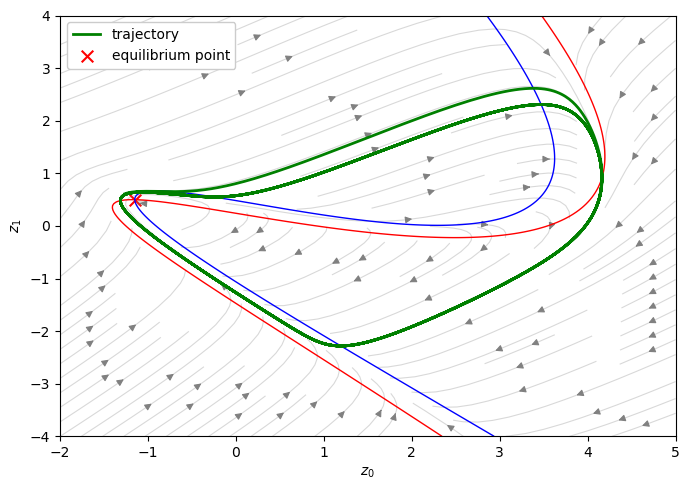

In [12]:
phase_plane_completo(traj=(t, X), eqs=eqs)

In [ ]:
def phase_plane_completo(x0_lim=(-2,5), 
                         x1_lim=(-3,3),
                         grid_stream=25, 
                         grid_null=200,
                         density=1.0, 
                         color='gray',
                         alpha=0.3, 
                         traj=None, 
                         eqs=None):

    x0_min, x0_max = x0_lim
    x1_min, x1_max = x1_lim

    X0s, X1s = np.meshgrid(
        np.linspace(x0_min, x0_max, grid_stream),
        np.linspace(x1_min, x1_max, grid_stream)
    )

    U = np.zeros_like(X0s)
    V = np.zeros_like(X1s)

    for i in range(X0s.shape[0]):
        for j in range(X0s.shape[1]):
            dx = f(0.0, np.array([X0s[i, j], X1s[i, j]]), u=0.0)
            U[i, j] = dx[0]
            V[i, j] = dx[1]

    x0 = np.linspace(x0_min, x0_max, grid_null)
    x1 = np.linspace(x1_min, x1_max, grid_null)
    X0n, X1n = np.meshgrid(x0, x1)

    F0 = np.zeros_like(X0n)
    F1 = np.zeros_like(X1n)

    for i in range(grid_null):
        for j in range(grid_null):
            dx = f(0.0, np.array([X0n[i, j], X1n[i, j]]), u=0.0)
            F0[i, j] = dx[0]
            F1[i, j] = dx[1]

    plt.figure(figsize=(7,5))

    sp = plt.streamplot(
        X0s, X1s, U, V,
        density=density,
        color=color,
        linewidth=0.8
    )

    sp.lines.set_alpha(alpha)
    sp.arrows.set_alpha(alpha)

    # trajetória
    if traj is not None:
        tt, XX = traj
        plt.plot(XX[0], XX[1], color='tab:blue', linewidth=1.2, label='trajectory')

    plt.xlabel('$z_0$')
    plt.ylabel('$z_1$')
    # plt.title("Plano de fase + nullclines")

    if (traj is not None) or (eqs is not None and eqs.shape[0] > 0):
        plt.legend(loc='upper left', frameon=True, framealpha=1.0)

    plt.savefig('phase-plane-pca.pdf', dpi=300)
    plt.show()

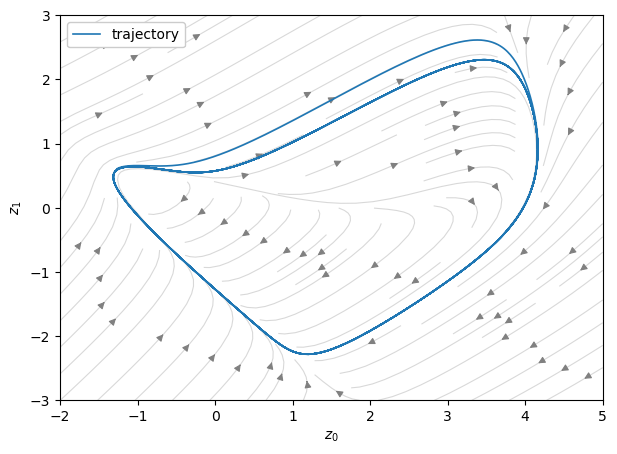

In [14]:
phase_plane_completo(traj=(t, X), eqs=eqs)

Initial conditions

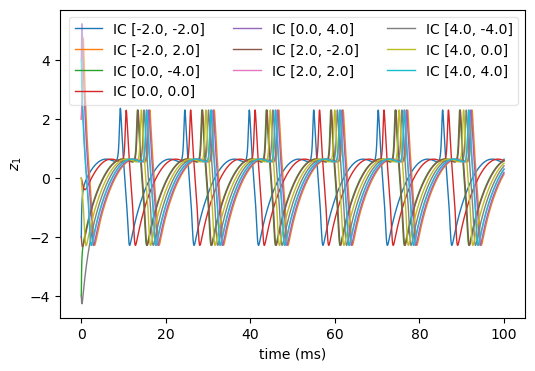

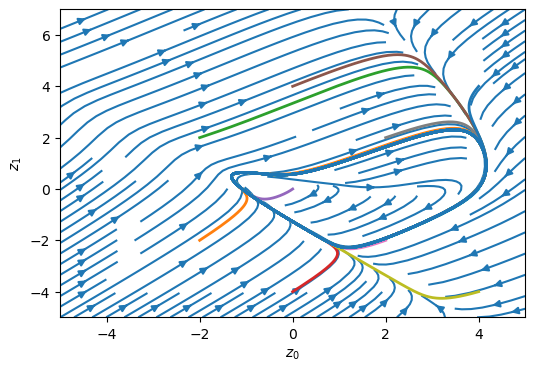

In [ ]:
y0_variations = [
    [-2.0, -2.0],
    [-2.0,  2.0],

    [ 0.0, -4.0],
    [ 0.0,  0.0],
    [ 0.0,  4.0],

    [ 2.0, -2.0],
    [ 2.0,  2.0],

    [ 4.0, -4.0],
    [ 4.0,  0.0],
    [ 4.0,  4.0],
]

tf = 100.0
dt = 0.01

plt.figure(figsize=(6,4))
for y0 in y0_variations:
    t, X = simulate_rk4(y0, tf=tf, dt=dt)
    plt.plot(t, X[1], linewidth=1, label=f"IC {y0}")
plt.xlabel('time (ms)')
plt.ylabel('$z_1$')
plt.legend(loc='upper right', frameon=True, framealpha=0.5, ncol=3)
plt.show()

plt.figure(figsize=(6,4))
grid_pp = 22
xx0 = np.linspace(-5, 5, grid_pp)
xx1 = np.linspace(-5, 7, grid_pp)
PP0, PP1 = np.meshgrid(xx0, xx1)
U = np.zeros_like(PP0)
V = np.zeros_like(PP1)
for i in range(grid_pp):
    for j in range(grid_pp):
        d = f(0.0, np.array([PP0[i,j], PP1[i,j]]), u=0.0)
        U[i,j], V[i,j] = d[0], d[1]
plt.streamplot(PP0, PP1, U, V, density=1.0)

for y0 in y0_variations:
    t, X = simulate_rk4(y0, tf=tf, dt=dt)
    plt.plot(X[0], X[1], linewidth=2)

plt.xlabel('$z_0$')
plt.ylabel('$z_1$')
plt.show()

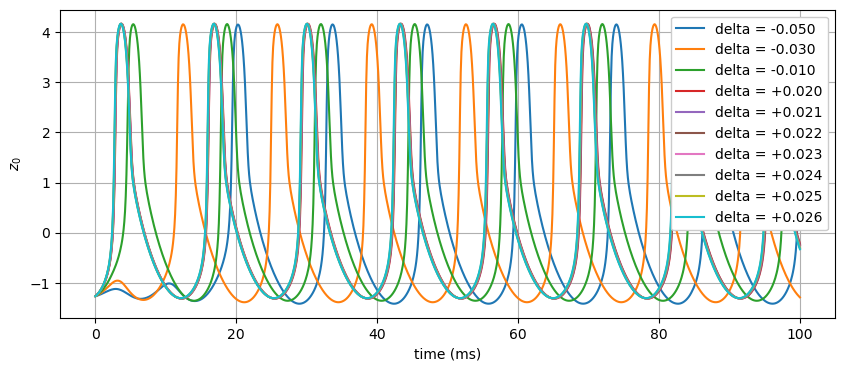

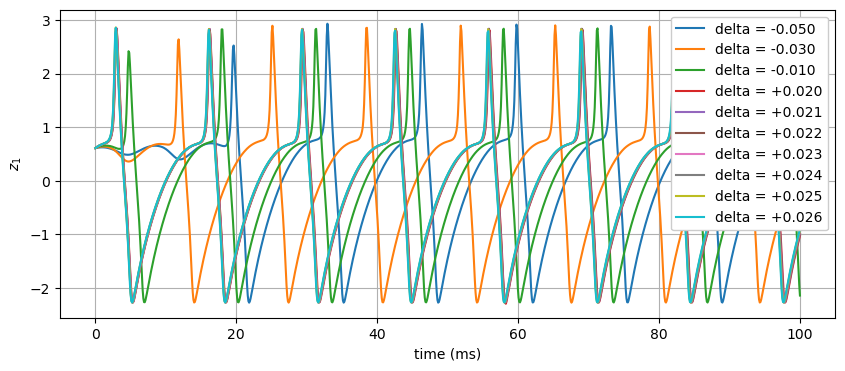

In [ ]:
t0 = 0.0
tf = 100.0
n_points = 1000
t_eval = np.linspace(t0, tf, n_points)

z0 = [-1.26607113,  0.60911538]

perturbacoes = np.array([
    -0.050, -0.030, -0.010, +0.020, +0.021,
    +0.022, +0.023, +0.024, +0.025, +0.026
])

resultados = []

for delta in perturbacoes:

    def modelo_perturbado(t, Z):
        z1, z2 = Z

        dz1 = ((-0.541 + delta) + 0.298*z1 + 1.849*z2 + 0.407*z1**2 + 1.675*z1*z2 + 1.284*z2**2 - 0.127*z1**3 - 0.390*z1**2*z2 - 0.422*z1*z2**2 - 0.141*z2**3)
        dz2 = ((-0.673 + delta) - 0.163*z1 + 0.839*z2+ 0.508*z1**2+ 1.663*z1*z2 + 1.230*z2**2 - 0.137*z1**3 - 0.409*z1**2*z2 - 0.423*z1*z2**2 - 0.144*z2**3)

        return [dz1, dz2]

    sol = solve_ivp(
        modelo_perturbado,
        (t0, tf),
        z0,
        t_eval=t_eval,
        method='RK45'
    )

    resultados.append({
        'delta': delta,
        't': sol.t,
        'z1': sol.y[0],
        'z2': sol.y[1]
    })

plt.figure(figsize=(10, 4))
for res in resultados:
    plt.plot(res['t'], res['z1'], label=f'delta = {res["delta"]:+.3f}')
plt.xlabel('time (ms)')
plt.ylabel('$z_0$')
plt.legend(loc='upper right', frameon=True, framealpha=1.0)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
for res in resultados:
    plt.plot(res['t'], res['z2'], label=f'delta = {res["delta"]:+.3f}')
plt.xlabel('time (ms)')
plt.ylabel('$z_1$')
plt.legend(loc='upper right', frameon=True, framealpha=1.0)
plt.grid(True)
plt.show()